# Final Anaylsis - Costumer Segmentation 

## Table of Contents

1. [Introduction & Setup](#1.-Introduction-&-Setup)
    * [1.1 Introduction](#1.1-Introduction)
    * [1.2 Setup](#1.2-Setup)
2. [Clustering Approaches](#2.-Clustering-Approaches)
    * [2.1 K-Means (1st Approach)](#2.1-K-Means-(1st-Approach))
    * [2.2 Hierarchical Clustering (2nd Approach)](#2.2-Hierarchical-Clustering-(2nd-Approach))
    * [2.3 Ensemble Clustering](#2.3-Ensemble-Clustering)
3. [Cluster Profiling & Insights](#3.-Cluster-Profiling-&-Insights)
    * [3.1 Core Cluster Profiling](#3.1-Core-Cluster-Profiling)
    * [3.2 Extended Demographic & Behavioral Profiling](#3.2-Extended-Demographic-&-Behavioral-Profiling)
4. [Association Rules (Market Basket Analysis)](#4.-Association-Rules-(Market-Basket-Analysis))
    * [4.1 Global Analysis (All Customers)](#4.1-Global-Analysis-(All-Customers))
    * [4.2 Cluster-Specific Analysis](#4.2-Cluster-Specific-Analysis)
5. [Final Conclusions & Business Recommendations](#5.-Final-Conclusions-&-Business-Recommendations)



## 1. Introduction & Setup

### 1.1 Introduction

This notebook contains the final data pipeline and modeling execution for our Customer Segmentation and Market Basket Analysis project. 
While the comprehensive business context and detailed theoretical justifications are provided in the **Final Report**, this notebook serves as the practical implementation of our methodology. 

### 1.2 Setup

In [20]:
# 1. Base Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 2. Scikit-Learn & UMAP
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
import umap

import importlib

# 3. Custom Modules - Preprocessing
import Preprocessing
importlib.reload(Preprocessing)
from Preprocessing import (preprocess_data_minmaxscaler, cluster_analysis)

# 4. Custom Modules - Clustering
import Clustering
importlib.reload(Clustering)
from Clustering import (
    find_optimal_k, fit_kmeans, fit_hierarchical, 
    find_optimal_eps, fit_dbscan, fit_som, 
    get_som_cluster_labels, assign_som_clusters, 
    compare_models, plot_umap, plot_tsne
)

# 5. Custom Modules - Association Rules
import AssociationRules
importlib.reload(AssociationRules)
from AssociationRules import (
    load_and_prepare_data, 
    convert_string_to_list,
    perform_global_analysis,
    perform_cluster_analysis
)


In [14]:
df = pd.read_csv('customer_info_engineered.csv')

In [15]:
clustering_data = df[['loyalty_product_type','lifetime_spend_vegetables_prop', 'lifetime_spend_meat_prop', 'lifetime_spend_hygiene_prop', 'lifetime_spend_videogames_prop', 'lifetime_spend_petfood_prop']]

In [16]:
clustering_method = preprocess_data_minmaxscaler(clustering_data)

## 2. Clustering Approaches

### 2.1 K-Means (1st Approach)

In [17]:
# Fit the final K-Means model with the optimal k=6 clusters
kmeans_profile_mm = fit_kmeans(clustering_method, 6)
kmeans_profile_mm

Silhouette Score: 0.4168
Cluster sizes:
0     2948
1     3286
2    19678
3     1056
4     2648
5     3422
Name: count, dtype: int64


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
loyalty_product_type,0.002429,0.005497,0.003618,0.002177,0.002188,0.004207
lifetime_spend_vegetables_prop,0.208170,0.029143,0.048557,0.514087,0.125996,0.264790
lifetime_spend_meat_prop,0.029338,0.101605,0.083774,0.033944,0.231243,0.021787
lifetime_spend_hygiene_prop,0.316024,0.039129,0.075648,0.284365,0.181342,0.103911
lifetime_spend_videogames_prop,0.034101,0.283766,0.038235,0.100882,0.085794,0.045312
lifetime_spend_petfood_prop,0.114839,0.068160,0.065284,0.162206,0.190056,0.072035


#### UMAP Visualization

UMAP dimensionality reduction provides a visual validation of our K-Means model, showing the spatial distribution of the 6 identified segments.

In [18]:
# Fit KMeans to get cluster labels for UMAP visualization
kmeans_opt_mm = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans_mm = kmeans_opt_mm.fit_predict(clustering_method)
labels_kmeans = labels_kmeans_mm #in order to run faster

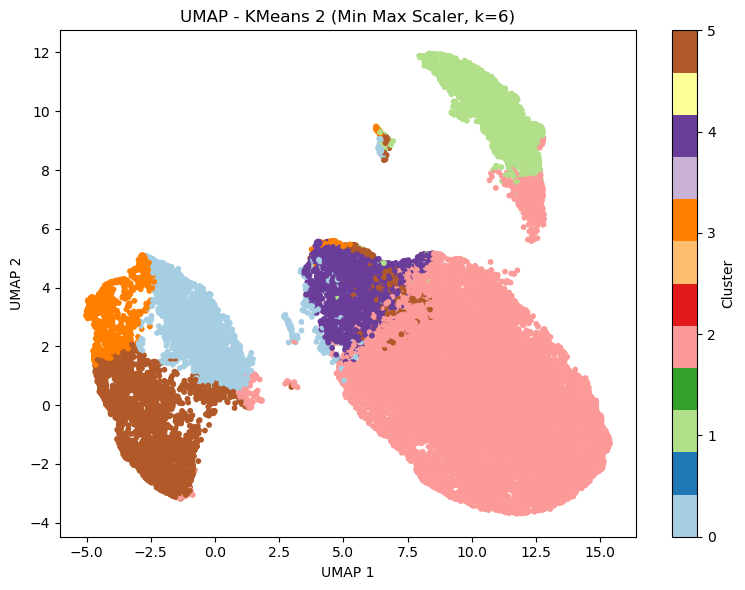

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [21]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(clustering_method, labels_kmeans, title="UMAP - KMeans 2 (Min Max Scaler, k=6)")

#### 3D Visualization
This plot shows the cluster structure in a second embedding view for comparison.


In [22]:
# Purpose: Provide a 3D overview of cluster separation in original feature space.
dados_para_plot = clustering_method.copy()
labels_dos_clusters = labels_kmeans

# 1. Run UMAP (3 components) for interactive 3D plotting
umap_3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
components_3d = umap_3d.fit_transform(dados_para_plot)

# 2. Build DataFrame for Plotly
df_3d = pd.DataFrame(components_3d, columns=['UMAP 1', 'UMAP 2', 'UMAP 3'])
df_3d['Cluster'] = labels_dos_clusters.astype(str)

# 3. Interactive 3D scatter: helps validate cluster separation visually
fig = px.scatter_3d(
    df_3d, x='UMAP 1', y='UMAP 2', z='UMAP 3', color='Cluster',
    title="3D Cluster Visualization (UMAP)", opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(marker=dict(size=4))
fig.show()


### 2.2 Hierarchical Clustering (2nd Approach)

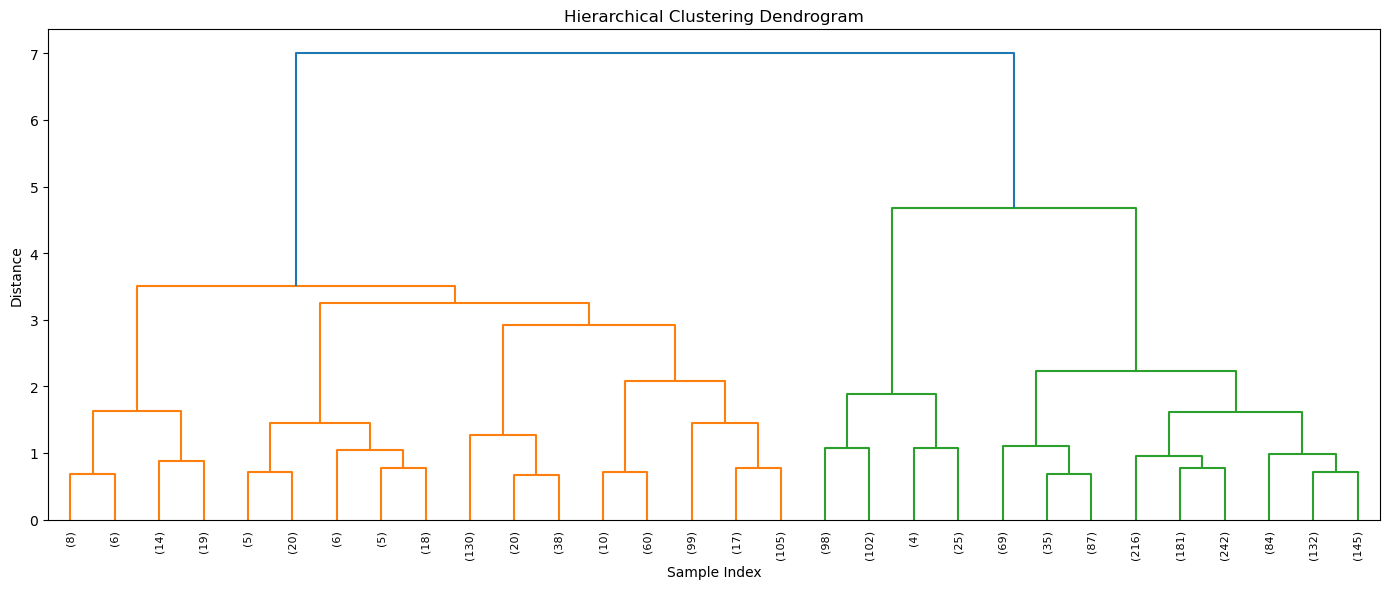

Silhouette Score: 0.3788
Cluster sizes:
0    21008
1     3111
2     3911
3     1467
4      993
5     2548
Name: count, dtype: int64


In [23]:
# Fit the Hierarchical Agglomerative Clustering model with 6 clusters (Ward's linkage)
hierarchical_model_mm, labels_hierarchical_mm, cluster_profile_hierarchical_mm = fit_hierarchical(clustering_method, 6, method='ward')

In [24]:
display(cluster_profile_hierarchical_mm)

,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
loyalty_product_type,0.003542,0.002408,0.005606,0.001610,0.003078,0.003788
lifetime_spend_vegetables_prop,0.057589,0.226602,0.038688,0.138652,0.505114,0.265504
lifetime_spend_meat_prop,0.093661,0.022817,0.093685,0.239736,0.015646,0.007598
lifetime_spend_hygiene_prop,0.081470,0.308753,0.045955,0.251615,0.214933,0.098338
lifetime_spend_videogames_prop,0.038889,0.027890,0.264613,0.102046,0.082914,0.040609
lifetime_spend_petfood_prop,0.072117,0.116575,0.065778,0.229426,0.131972,0.065016


#### UMAP Visualization

A 2D UMAP projection illustrating the cluster separation achieved by the Hierarchical Agglomerative model.

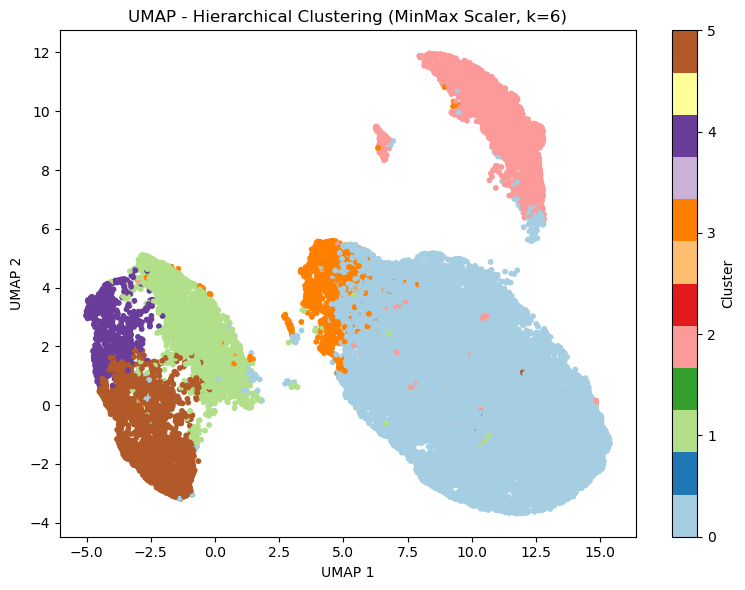

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [25]:
plot_umap(clustering_method, labels_hierarchical_mm, title="UMAP - Hierarchical Clustering (MinMax Scaler, k=6)")

### 2.3 Esemble Clustering


In this section, we apply an Ensemble Clustering approach to build a more robust customer segmentation. Instead of relying on a single algorithm's assumptions, we use a "Meta-Learning" strategy. First, we take the cluster assignments (labels) predicted by our independent base models and use them as new categorical features. We then apply a **Meta-Learner** — in our case, a final **K-Means** algorithm—on top of these labels. By clustering the predictions of previous models rather than the raw data, this final model identifies the consensus groupings, combining the strengths of the individual algorithms.

In [26]:
# 1. Base Variables
predictions_kmeans = labels_kmeans
predictions_hierarchical = labels_hierarchical_mm 
df_original_data = clustering_method 

# 2. DataFrame for the Ensemble
df_ensemble = pd.DataFrame({
    'KMeans_Base': predictions_kmeans.astype(str),
    'Hierarchical_Base': predictions_hierarchical.astype(str)
})
df_ensemble_encoded = pd.get_dummies(df_ensemble)

# 3. Final K-Means (Meta-Learner)
k_final = 6
kmeans_ensemble = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_ensemble_final = kmeans_ensemble.fit_predict(df_ensemble_encoded)

# 4. Silhouette Score Calculation
sil_score = silhouette_score(df_original_data, labels_ensemble_final)
print(f"The Silhouette Score of the Final Ensemble is: {sil_score:.4f}")


The Silhouette Score of the Final Ensemble is: 0.3926


#### UMAP Visualization

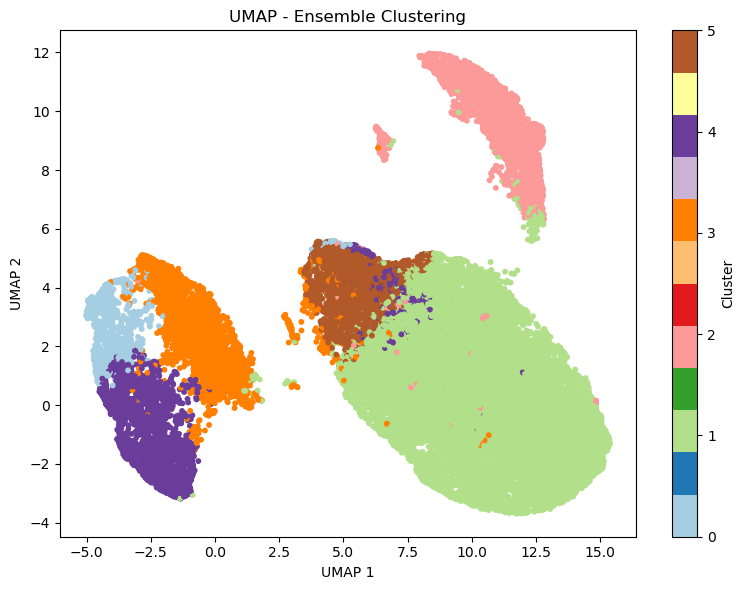

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [ ]:
plot_umap(df_original_data, labels_ensemble_final, title="UMAP - Ensemble Clustering")


### Ensemble model choice and silhouette comparison
The ensemble model is selected as the best solution because it combines KMeans and hierarchical cluster assignments into a more robust consensus segmentation.
Its silhouette score is lower than some individual models, but it is more stable and better suited for real business interpretation.
This means the ensemble is favored for robustness and reliable customer segment definitions, even if it sacrifices a small amount of silhouette quality.


In [28]:
# Purpose: Create a cluster profile table using original real-valued features.
numeric_variables = clustering_data.select_dtypes(include=['number']).copy()
cluster_profile = numeric_variables.groupby(labels_ensemble_final).mean().T

cluster_profile.columns = [f"Cluster {int(c)}" for c in cluster_profile.columns]

print('Original data cluster profile (real values):')
display(cluster_profile)


Original data cluster profile (real values):


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
loyalty_product_type,280.912163,332.266424,527.300960,233.128936,396.232807,206.100789
lifetime_spend_vegetables_prop,0.225661,0.018235,0.014992,0.086786,0.105517,0.049228
lifetime_spend_meat_prop,0.011936,0.034754,0.038736,0.011667,0.009374,0.098127
lifetime_spend_hygiene_prop,0.083761,0.028604,0.017382,0.122296,0.035945,0.069775
lifetime_spend_videogames_prop,0.021865,0.009298,0.070404,0.008006,0.010823,0.022298
lifetime_spend_petfood_prop,0.030184,0.014114,0.014155,0.025327,0.014699,0.041401


### Original data cluster profile table - MUDAR
**Mini importance:** Use the original-value averages to assign human-readable labels to clusters (e.g., 'Pet owners', 'High-value buyers').
The previous table shows average feature values for each ensemble cluster using the original dataset.
This table is the baseline for understanding the practical meaning of each segment.


In [ ]:

df['cluster'] = labels_ensemble_final  # podemos por aqui tratar aqui do costumer id

# O reset_index() garante que o ID do cliente vira uma coluna gravada no CSV
df.to_csv('dataset_clusters.csv', index=False)

In [24]:
read_csv = pd.read_csv('dataset_clusters.csv')
read_csv.head()

,index,customer_name,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_electronics_prop,lifetime_spend_vegetables_prop,lifetime_spend_nonalcohol_drinks_prop,lifetime_spend_alcohol_drinks_prop,lifetime_spend_meat_prop,lifetime_spend_fish_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop,cluster
0,0,Bsc. Crystal Kitchens,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,...,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656,1
1,1,Bsc. Glenda Bauman,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,...,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867,3
2,2,Msc. Antonio Campbell,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,...,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277,1
3,3,John Kelling,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,...,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306,2
4,4,Arthur Dematteo,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,...,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095,2


## 3. Cluster Profiling & Insights


### 3.1 Core Cluster Profiling

#### Size of the Clusters

Cluster 1 is the dominant segment with 57.7% of customers (19,047).
Remaining clusters range from 3.2% to 11.9% of the customer base.

In [10]:

pd.Series(labels_ensemble_final).value_counts(ascending=True)


5     1268
2     2648
0     2944
4     3252
3     3879
1    19047
Name: count, dtype: int64

<Axes: title={'center': 'Size of the Clusters'}, ylabel='count'>

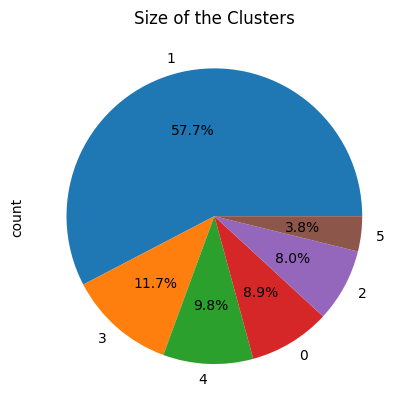

In [11]:

pd.Series(labels_ensemble_final).value_counts().plot.pie(autopct='%1.1f%%', title='Size of the Clusters')


#### Radar Charts

The radar charts below provide a multi-dimensional view of each cluster, highlighting the unique spending patterns and dominant product categories for every customer segment.

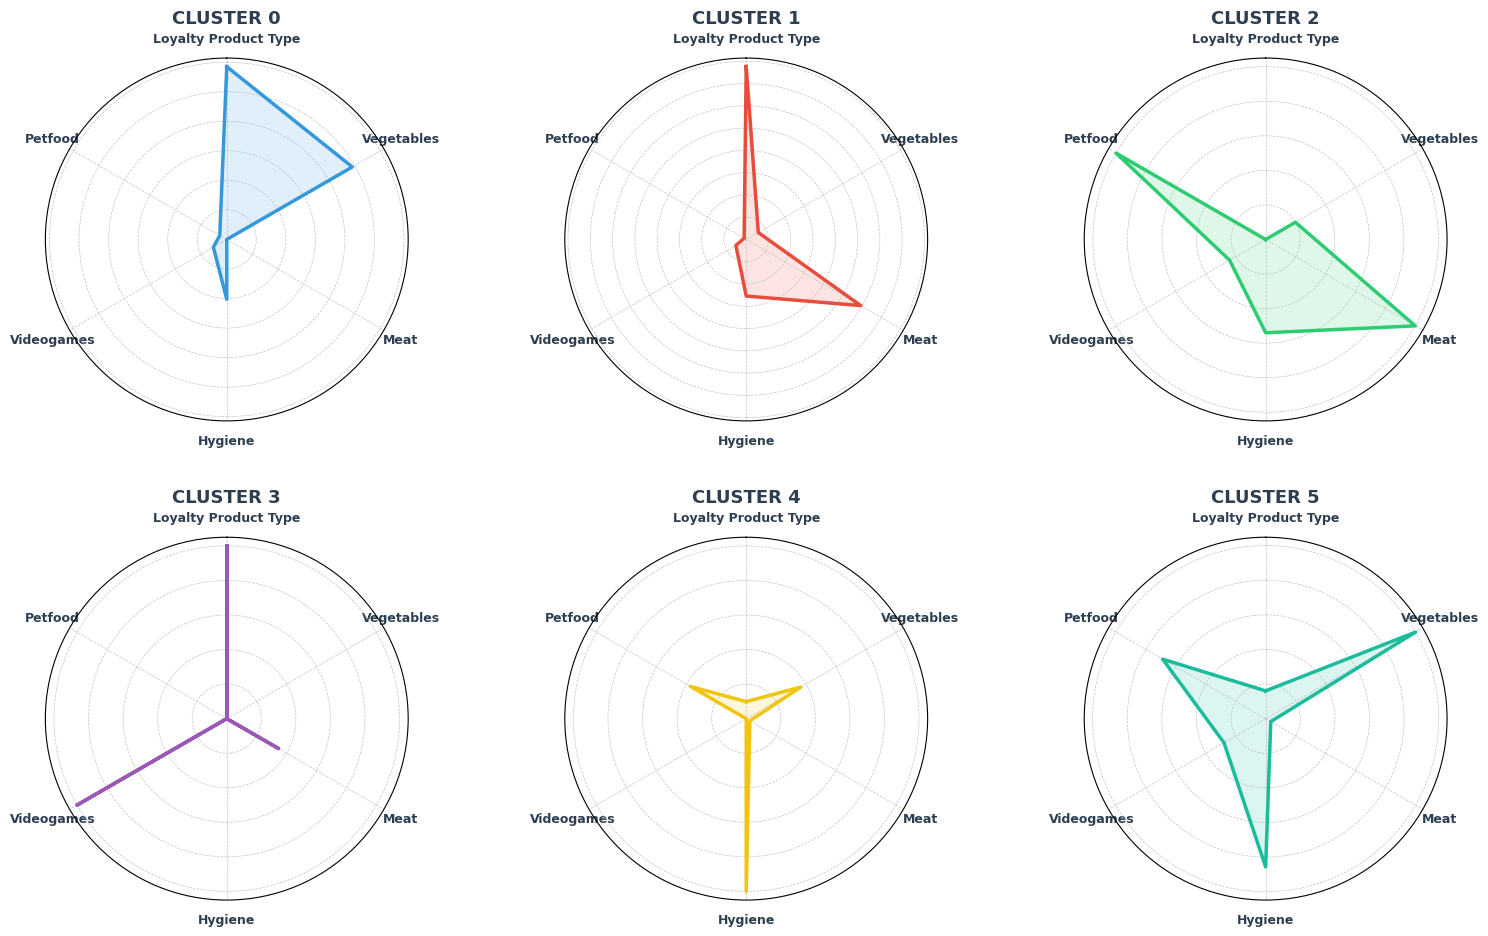

In [ ]:

# Purpose: Radar charts compare normalized feature profiles across clusters for multi-dimensional interpretation.
numeric_vars = clustering_method.select_dtypes(include=['number']).copy()
perfil_ensemble = numeric_vars.groupby(labels_ensemble_final).mean()

# ----------------------------------------------------------------------------------
# Why apply MinMaxScaler again here?
# ----------------------------------------------------------------------------------
# The first scaler was applied to individual customers. 
# Here, we scale the cluster averages.
# This forces the highest cluster average to 1.0 and the lowest to 0.0 for each feature, 
# which stretches the radar chart and makes the visual differences between clusters much clearer.
# ----------------------------------------------------------------------------------

# Normalize 0-1 so all variables fit harmoniously on the radar
scaler = MinMaxScaler()
perfil_normalized = pd.DataFrame(
    scaler.fit_transform(perfil_ensemble), 
    columns=perfil_ensemble.columns, 
    index=perfil_ensemble.index
)

# Axis and label cleanup
categories = list(perfil_normalized.columns)
categories_clean = [c.replace('lifetime_spend_', '').replace('_prop', '').replace('_', ' ').title() for c in categories]
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the circle

# Create dynamic grid for cluster plots
num_clusters = len(perfil_normalized)
cols = 3
rows = int(np.ceil(num_clusters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), subplot_kw=dict(polar=True))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f1c40f', '#1abc9c']

for idx, cluster_id in enumerate(perfil_normalized.index):
    ax = axes[idx]
    values = perfil_normalized.loc[cluster_id].values.tolist()
    values += values[:1]

    color = colors[idx % len(colors)]
    ax.plot(angles, values, color=color, linewidth=2.5, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.15)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories_clean, color='#2c3e50', size=9, fontweight='bold')

    ax.set_yticklabels([])
    ax.grid(color='#bdc3c7', linestyle='--', linewidth=0.5)

    ax.set_title(f'CLUSTER {int(cluster_id)}', size=13, color='#2c3e50', weight='bold', pad=25)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()


#### Category Purchase Penetration by Cluster
*Out of every 100 customers in this cluster, how many purchased this category at least once?*

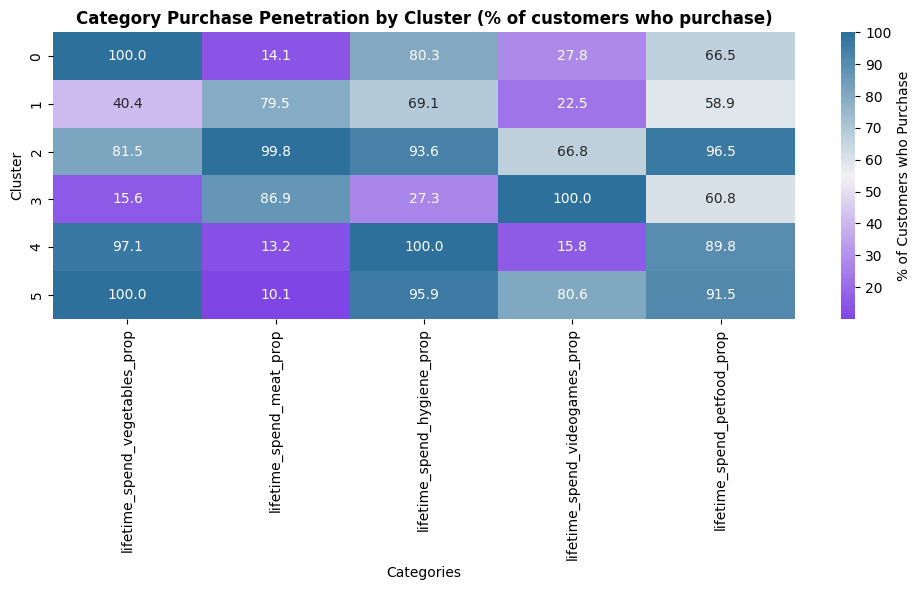

In [ ]:
# Purpose: Show the percent of customers in each cluster who purchase each category (penetration).
category_props = [c for c in df_original_data.columns if '_prop' in c] # NÃO SEI O QUE SE PASSA
df_binary = (df_original_data[category_props] > 0.05).astype(int)
df_binary['Cluster'] = labels_ensemble_final

penetration_matrix = df_binary.groupby('Cluster').mean() * 100
indigo_divergent = sns.diverging_palette(275, 240, s=85, l=45, center="light", as_cmap=True)


plt.figure(figsize=(10, 6))
sns.heatmap(penetration_matrix, annot=True, fmt=".1f", cmap=indigo_divergent, cbar_kws={'label': '% of Customers who Purchase'})
plt.title('Category Purchase Penetration by Cluster (% of customers who purchase)', fontsize=12, fontweight='bold')
plt.ylabel('Cluster')
plt.xlabel('Categories')
plt.tight_layout()
plt.show()

#### Key Strategic Takeaways

* **The Specialist vs. Generalist Divide:** 
Clusters 3 and 4 are mission-driven specialists (Games and Hygiene). They require highly targeted, category-specific communication. 
Clusters 2 and 5 are lifestyle generalists. They build their entire routines around the store, making them the most valuable segments for driving overall store revenue.

* **The Dietary Polarization:** 
The stark visual contrast between Cluster 0 (Pure Greens) and Cluster 1 (Pure Meat) proves that a generic, one-size-fits-all grocery campaign will fail. Marketing efforts for food must be strictly split into plant-based/wellness tracks versus traditional meat/protein tracks.

* **Pet Food as an Ecosystem Driver:** 
For the high-spending clusters, pet food is an absolute magnet. When pet owners trust the store for their animals, they naturally migrate the rest of their premium household shopping there.

### 3.2 Extended Demographic & Behavioral Profiling

In [14]:
# 1. Obter os dados reais limpos pela sua função
df_real = cluster_analysis(df.copy())

# 2. Adicionar as labels do seu modelo Ensemble
df_real['Cluster'] = labels_ensemble_final

#### Distributions of all features per cluster

In [50]:
# 3. Filter absolute spending columns
cols_to_remove = [col for col in df_real.columns if 'lifetime_spend' in col and 'prop' not in col]
if 'total_lifetime_spend' in df_real.columns:
    cols_to_remove.append('total_lifetime_spend')

# Add demographic/identifier columns that don't make sense for the mean profile
extra_cols_to_remove = [
    'customer_id', 
    'customer_name', 
    'latitude', 
    'longitude', 'female',
    'has_loyalty_card', 'year_first_transaction'
]
cols_to_remove.extend(extra_cols_to_remove)

# 4. Remove the columns, group by cluster, and calculate the mean
# Using errors='ignore' prevents breaking if the column is already dropped
df_means = df_real.drop(columns=cols_to_remove, errors='ignore').groupby('Cluster').mean().T

# Rename columns to "Cluster 0", "Cluster 1", etc.
df_means.columns = [f"Cluster {int(c)}" for c in df_means.columns]

# 5. Display the formatted DataFrame with a row-wise heatmap gradient
# (Using 'RdYlBu' because it's better for gradients than 'Paired')
df_means.style.background_gradient(cmap='RdYlBu', axis=1)



,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
number_complaints,0.803802,0.995957,1.036359,0.599241,0.794497,0.942674
distinct_stores_visited,3.275285,3.284748,1.832687,3.589781,3.271060,3.592976
typical_hour,13.947148,11.904363,16.675166,10.907212,13.762228,12.655287
lifetime_total_distinct_products,84.454373,176.506274,109.649669,126.896058,87.535326,130.933535
percentage_of_products_bought_promotion,0.130279,0.406575,0.289200,0.184123,0.165960,0.489197
age,57.790494,53.187977,55.491382,56.824584,56.641576,56.792900
total_kids,1.883650,2.361674,0.802703,1.893664,1.893274,1.664879
loyalty_product_type,280.912163,332.266424,527.300960,233.128936,396.232807,206.100789
lifetime_spend_groceries_prop,0.290067,0.553284,0.331377,0.483275,0.508547,0.388399
lifetime_spend_electronics_prop,0.159641,0.074606,0.275574,0.052837,0.097066,0.095065



#### Key Strategic Takeaways

* **Wallet Share vs. Niche Budgets:** 
Traditional groceries dominate the budget for almost everyone (28% to 55%). The big exception is Cluster 3 (Gamers), who disrupt this pattern by burning a massive 27.6% of their entire lifetime budget on Electronics.

* **Deal Hunters vs. Premium Shoppers:** 
**Cluster 2** are pure promo hunters, buying 48.9% of their items on discount across a massive variety of products. On the flip side, Cluster 5 are premium organic shoppers who rarely buy on sale (13.6% promotion rate), willingly paying full price for vegetables and hygiene.

* **The Family Size Factor:** 
Demographics explain the basket sizes. Cluster 1 represents large families (2.36 kids), driving a massive variety of grocery needs (176 distinct products). Cluster 3 has the fewest kids (0.79), shops late in the afternoon (~16:43), sticks to very few stores (1.8), and is the most critical segment with the highest complaint rate.

#### Commercial Value: Individual Customer Quality vs. Overall Segment Volume

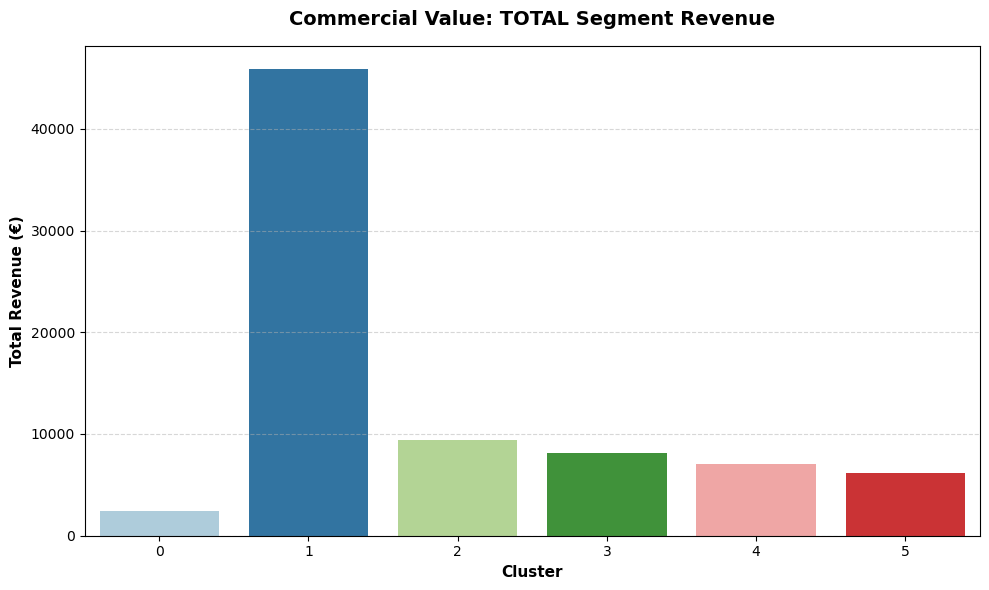

In [49]:


# Calculate the Sum (Total Segment Revenue)
df_sum = df_real.groupby('Cluster')['total_lifetime_spend'].sum().reset_index()

# Create a single plot
plt.figure(figsize=(10, 6))

# THE SUM (Volume/Total Revenue for the Company)
sns.barplot(x='Cluster', y='total_lifetime_spend', data=df_sum, palette='Paired')

# Titles and Labels
plt.title('Commercial Value: TOTAL Segment Revenue', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Revenue (€)', fontweight='bold', fontsize=11)
plt.xlabel('Cluster', fontweight='bold', fontsize=11)

# Add a subtle grid to make reading the values easier
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()





#### Key Strategic Takeaways: Value vs. Volume

* **The Revenue Giant (Cluster 1):** Looking at total segment revenue, Cluster 1 is the undisputed powerhouse, generating over €45,000—more than all other clusters combined. However, this financial impact is driven entirely by its sheer volume of customers rather than high individual spend. 

* **The Small Premium Niche (Cluster 5):** Despite purchasing premium wellness items at full price, Cluster 5 generates the lowest total revenue (under €3,000) simply because it represents a very small fraction of the customer base.

* **The Bottom Line:** While niche segments (like Clusters 3 and 5) are excellent targets for specialized, high-margin marketing campaigns, Cluster 1 remains the financial backbone of the business. From a risk perspective, a tiny drop in Cluster 1's retention will hurt the total bottom line far more than losing an entire niche group.


#### Gender Anaylsis per Cluster

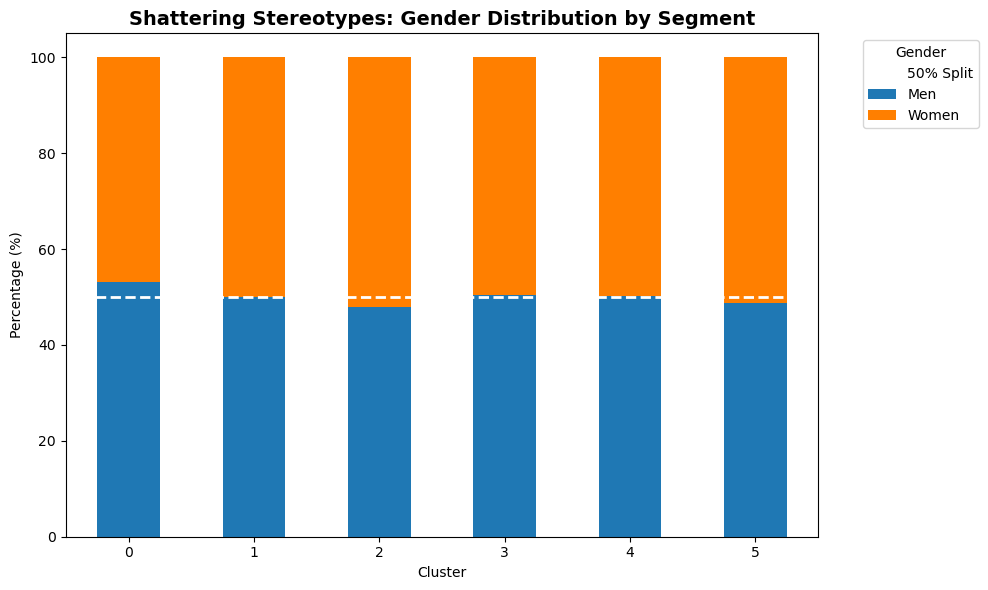

In [51]:
# Calculate the proportion of Men (0) and Women (1) in each cluster
df_gender = df_real.groupby('Cluster')['female'].value_counts(normalize=True).unstack()
df_gender.columns = ['Men', 'Women']
df_gender = df_gender * 100 # Convert to percentage

# Draw the 100% stacked bar chart
ax = df_gender.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=['#1f78b4', '#ff7f00'] # Contrasting colors (Dark Blue and Red)
)

plt.title('Shattering Stereotypes: Gender Distribution by Segment', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Cluster')

# Draw a line exactly at 50% to visually prove the point!
plt.axhline(50, color='white', linestyle='--', linewidth=2, label='50% Split')

# Move the legend outside the plot area
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Keep X labels horizontal
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Gender is entirely irrelevant for targeting these segments: Every cluster has a perfect 50/50 split, proving that shopping behavior and product loyalty are completely independent of gender.

#### Loyalty Card Anaylsis per Cluster

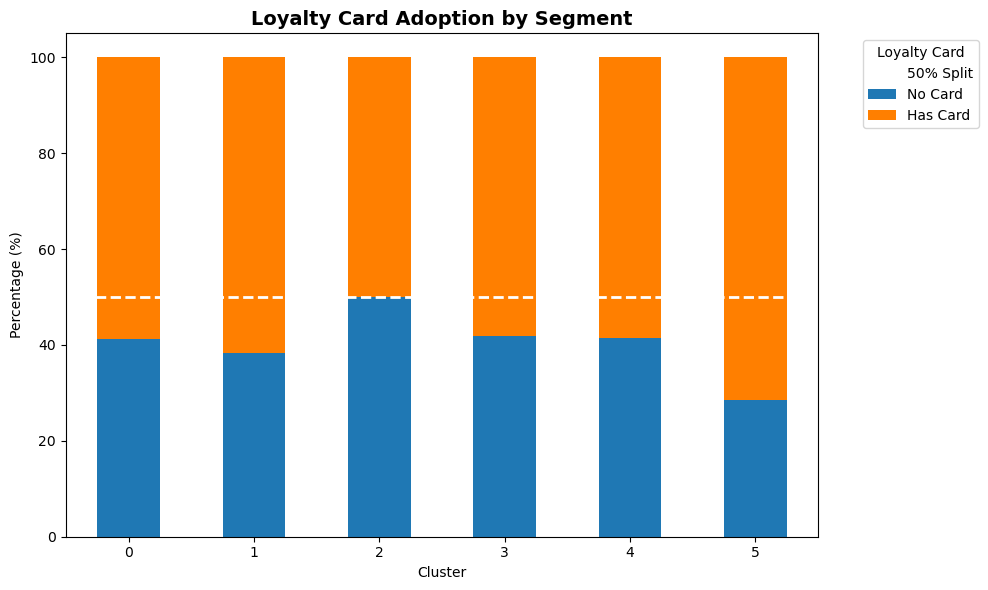

In [53]:
# Calculate the proportion of Men (0) and Women (1) in each cluster
df_loyalty = df_real.groupby('Cluster')['has_loyalty_card'].value_counts(normalize=True).unstack()
df_loyalty.columns = ['No Card', 'Has Card']
df_loyalty = df_loyalty * 100 # Convert to percentage

# Draw the 100% stacked bar chart
ax = df_loyalty.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=['#1f78b4', '#ff7f00'] # Contrasting colors (Dark Blue and Red)
)

plt.title('Loyalty Card Adoption by Segment', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Cluster')

# Draw a line exactly at 50% to visually prove the point!
plt.axhline(50, color='white', linestyle='--', linewidth=2, label='50% Split')

# Move the legend outside the plot area
plt.legend(title='Loyalty Card', bbox_to_anchor=(1.05, 1), loc='upper left')

# Keep X labels horizontal
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Key Strategic Takeaways: Loyalty Card Adoption

* **The Engagement Leader (Cluster 2):** Pet Parents have the highest card adoption rate (over 70%), using it actively to maximize rewards across their large household baskets.
* **The Dangerous Retention Gap (Cluster 3):** Gamers are your biggest flight risk, with the lowest card adoption rate (a flat 50% split). 
* **The Bottom Line:** Your loyalty program is highly attractive to traditional families but fails to connect with tech/entertainment buyers; the rewards system needs to be gamified or adapted to digital products to capture Cluster 3.

#### Boxplots


These plots use original customer features from the dataset, including age, total lifetime spend, promotion purchase share, and complaints.
The stacked bar charts show loyalty card adoption and gender distribution by cluster, which are important for translating cluster segments into marketing and retention actions.

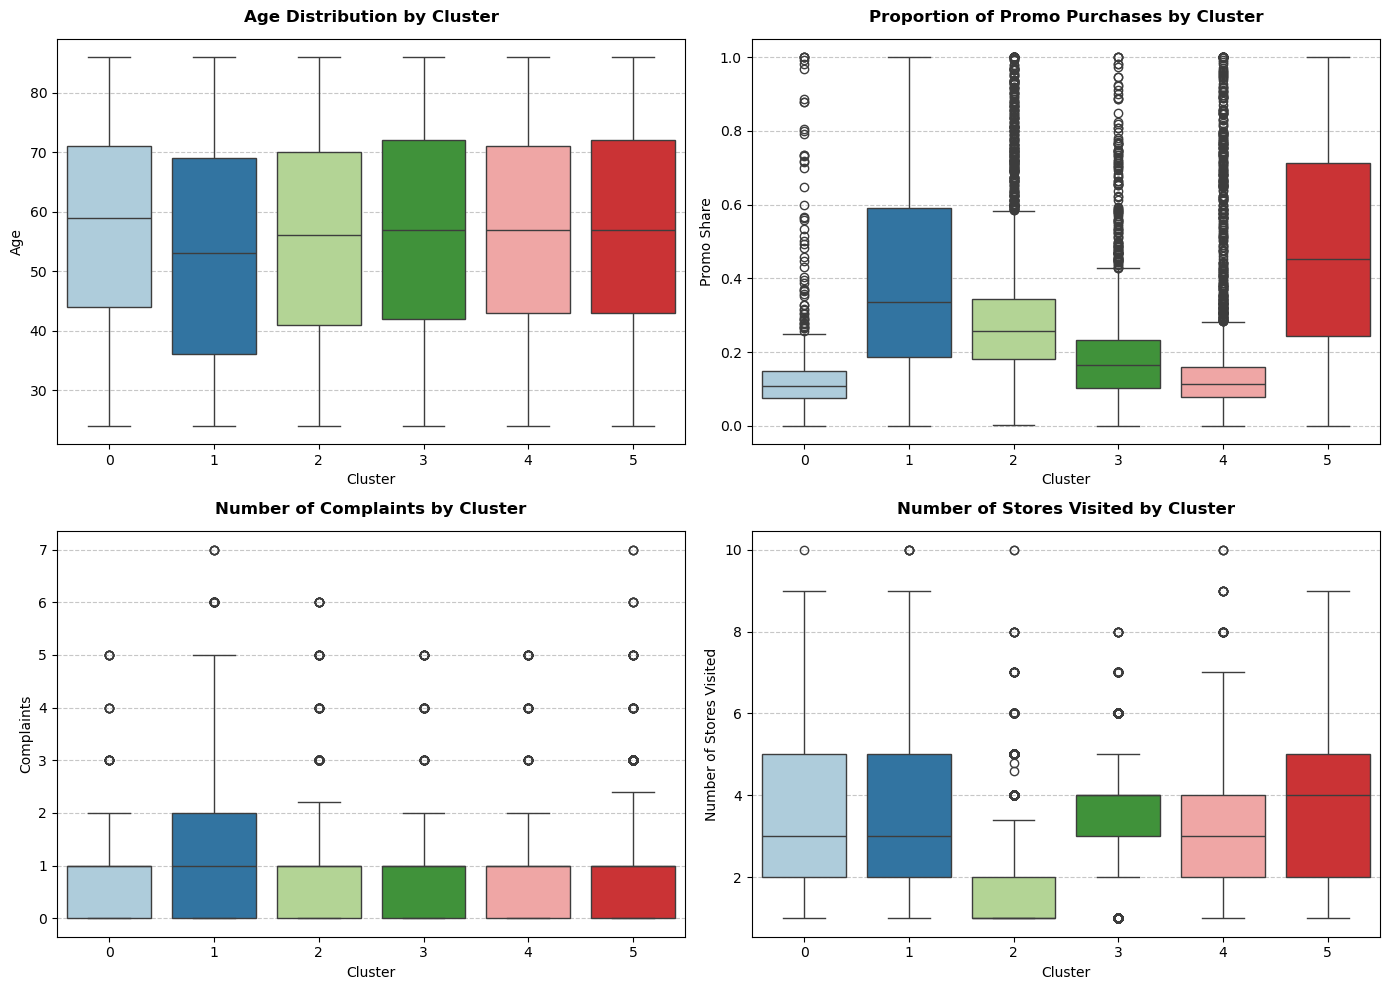

In [48]:
vars_num = ['age', 'percentage_of_products_bought_promotion', 'number_complaints', 'distinct_stores_visited']
titles_num = ['Age Distribution by Cluster','Proportion of Promo Purchases by Cluster', 'Number of Complaints by Cluster', 'Number of Stores Visited by Cluster']
ylabels = ['Age', 'Promo Share', 'Complaints', 'Number of Stores Visited']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(vars_num):
    sns.boxplot(data=df_real, x='Cluster', y=var, ax=axes[idx], palette='Paired', hue='Cluster', legend=False)
    axes[idx].set_title(titles_num[idx], fontweight='bold', pad=12)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(ylabels[idx])
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



#### Geographic Anaylsis

In [ ]:
# Purpose: Map ensemble clusters geographically to check whether segments correlate with location.
df_mapa = df_real.copy()
df_mapa['Cluster'] = labels_ensemble_final

geometry = [Point(xy) for xy in zip(df_mapa.longitude, df_mapa.latitude)]
customer_info_gd = gpd.GeoDataFrame(df_mapa, geometry=geometry, crs='EPSG:4326')

print('Generating the cluster geography map...')
cluster_map = customer_info_gd.iloc[0:1000].explore(
    column='Cluster',
    categorical=True,
    cmap='Set1',
    legend=True,
    marker_kwds=dict(radius=5, fill=True),
    tooltip=['customer_name', 'Cluster', 'total_lifetime_spend']
)

cluster_map

Generating the cluster geography map...


## 4.Cluster Names & Profiles

### Cluster 0: The Eco-Minded Matriarch/Patriarch

* **Category Penetration:** Vegetables (100.0%), Hygiene (80.3%), Petfood (66.5%), Videogames (27.8%), Meat (14.1%).
* **Spending Wallet Share:** Groceries (50.8%), Vegetables (10.0%), Electronics (9.7%), Hygiene (3.5%).
* **Demographics:** Average age 56.6 years, 1.89 children on average, 50% Men / 50% Women split.
* **Behavior & Value:** 0.79 complaints, 3.27 distinct stores visited, typical shopping hour ~13:45. Promotion adoption rate of 16.6%. Total Segment Revenue: ~€7,100. Loyalty Card Adoption: ~58%.
* **Profile:** Shopper focused on fresh food and natural items, concentrating budget on vegetables and hygiene while avoiding the meat category. Low promotion sensitivity.

---

### Cluster 1: The Plant-Based Household

* **Category Penetration:** Meat (79.5%), Hygiene (69.1%), Petfood (58.9%), Vegetables (40.4%), Videogames (22.5%).
* **Spending Wallet Share:** Groceries (55.3%), Electronics (7.4%), Meat (3.4%), Hygiene (2.8%).
* **Demographics:** Average age 53.2 years, 2.36 children on average (highest family volume), 50% Men / 50% Women split.
* **Behavior & Value:** 0.99 complaints, 3.28 distinct stores visited, typical shopping hour ~11:55. Highest volume of distinct products purchased: 176 items. Promotion adoption rate of 40.6%. Total Segment Revenue: >€45,000 (Highest financial volume of the business). Loyalty Card Adoption: ~62%.
* **Profile:** Responsible for high-volume purchases managing large family expenses. Consumption heavily focused on staple groceries and proteins, with high reliance on promotions for cost management.

---

### Cluster 2: The Promotion-Driven Pet Parent

* **Category Penetration:** Meat (99.8%), Petfood (96.5%), Hygiene (93.6%), Vegetables (81.5%), Videogames (66.8%).
* **Spending Wallet Share:** Groceries (38.8%), Electronics (9.5%), Meat (9.2%), Hygiene (6.6%), Fish (5.3%), Petfood (4.0%).
* **Demographics:** Average age 56.7 years, 1.66 children on average, 50% Men / 50% Women split.
* **Behavior & Value:** 0.94 complaints, 3.59 distinct stores visited (high store mobility), typical shopping hour ~12:40. Promotion adoption rate of 48.9% (Highest reliance on discounts). Total Segment Revenue: ~€6,200. Loyalty Card Adoption: >70% (Highest engagement with the program).
* **Profile:** Shopper with highly diversified baskets (130 distinct products) guided by extreme price sensitivity. Uses the loyalty card strategically to maximize discounts in recurring categories like meat and pet food.

---

### Cluster 3: The Demanding Premium Tech Consumer

* **Category Penetration:** Videogames (100.0%), Meat (86.9%), Petfood (60.8%), Hygiene (27.3%), Vegetables (15.6%).
* **Spending Wallet Share:** Groceries (33.2%), Electronics (27.6% - Highest allocation in this category), Videogames (6.6%), Alcohol (4.5%).
* **Demographics:** Average age 55.4 years, 0.79 children on average (predominantly childless profile), 50% Men / 50% Women split.
* **Behavior & Value:** 1.03 complaints (Highest level of dissatisfaction), 1.81 distinct stores visited (strict local routine), typical shopping hour ~16:43 (Late afternoon). Promotion adoption rate of 29.0%. Total Segment Revenue: ~€9,300. Loyalty Card Adoption: 50% (Largest retention gap for the brand).
* **Profile:** Consumer focused on entertainment, technology, and convenience, bypassing basic household needs like hygiene and fresh vegetables. Highly critical shopper with late purchasing habits and unlinked to the current loyalty program.

---

### Cluster 4: The Wellness Customer

* **Category Penetration:** Hygiene (100.0%), Vegetables (97.1%), Petfood (89.8%), Videogames (15.8%), Meat (13.2%).
* **Spending Wallet Share:** Groceries (49.5%), Hygiene (10.9% - Highest allocation in this category), Vegetables (7.7%), Non-Alcoholic Drinks (3.4%).
* **Demographics:** Average age 56.7 years, 1.89 children on average, 50% Men / 50% Women split.
* **Behavior & Value:** 0.59 complaints (Highest level of satisfaction / Least problematic), 3.58 distinct stores visited, typical shopping hour ~10:55 (Morning shopper). Promotion adoption rate of 18.4%. Total Segment Revenue: ~€7,700. Loyalty Card Adoption: ~58%.
* **Profile:** Customer focused on personal care routines and home maintenance. Uses the brand essentially as a pharmacy and drugstore, displaying low price sensitivity in hygiene and rejecting the meat section.

---

### Cluster 5: The Premium Organic Shopper

* **Category Penetration:** Vegetables (100.0%), Hygiene (95.9%), Petfood (91.5%), Videogames (80.6%), Meat (10.1%).
* **Spending Wallet Share:** Groceries (28.4%), Vegetables (19.8% - Absolute record for budget allocation), Electronics (14.8%), Hygiene (9.6%), Non-Alcoholic Drinks (4.7%).
* **Demographics:** Average age 57.7 years (Oldest segment), 1.89 children on average, 50% Men / 50% Women split.
* **Behavior & Value:** 0.78 complaints, 3.31 distinct stores visited, typical shopping hour ~13:27. Promotion adoption rate of 13.6% (Lowest index of discounted purchases - full price customer). Total Segment Revenue: <€3,000 (Smallest niche in terms of customer volume). Loyalty Card Adoption: ~58%.
* **Profile:** Consumer focused on quality, health, and premium product lines. Allocates a fifth of their entire budget to vegetables and accepts paying full price for items without dependency on promotional campaigns. High unit profit margin group.

## 5. Association Rules (Market Basket Analysis)

In [4]:
# Load and prepare data
df_basket_clusters = load_and_prepare_data(
    basket_path='customer_basket (1).csv', 
    clusters_path='dataset_clusters.csv'
)

# Parse list of goods
df_basket_clusters['list_of_goods_parsed'] = df_basket_clusters['list_of_goods'].apply(convert_string_to_list)

# Configure pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

print(f"✓ Data loaded: {len(df_basket_clusters)} transactions")
print(f"✓ Clusters found: {df_basket_clusters['cluster'].nunique()}")

Loading data files...
✓ Data loaded: 82516 transactions
✓ Clusters found: 6


### 5.1 Global Analysis (All Customers)

In [5]:
import importlib
import AssociationRules
importlib.reload(AssociationRules)
from AssociationRules import perform_global_analysis, perform_cluster_analysis

# Correr Análise Global (com valores de suporte e confidence configuráveis)
perform_global_analysis(df_basket_clusters, min_support=0.02, min_confidence=0.15)


=== PART 1: GLOBAL ASSOCIATION RULES (ALL CUSTOMERS COMBINED) ===

✓ Frequent Itemsets: 171
✓ Association Rules: 14


,antecedents,consequents,support,confidence,lift
0,[airpods],[energy drink],0.0245,0.2060,2.8112
1,[energy drink],[airpods],0.0245,0.3346,2.8112
2,[bluetooth headphones],[airpods],0.0237,0.3334,2.8008
3,[airpods],[bluetooth headphones],0.0237,0.1992,2.8008
4,[eggs],[cereals],0.0226,0.2430,2.4039
5,[cereals],[eggs],0.0226,0.2241,2.4039
6,[butter],[eggs],0.0209,0.2143,2.2993
7,[eggs],[butter],0.0209,0.2238,2.2993
8,[fresh bread],[cereals],0.0228,0.2305,2.2803
9,[cereals],[fresh bread],0.0228,0.2256,2.2803



lift Range: 0.7249 (Min: 2.0863, Max: 2.8112)


### 5.2 Cluster-Specific Analysis

In [6]:
# Correr Análise Específica por Cluster
perform_cluster_analysis(df_basket_clusters, min_support=0.02, min_confidence=0.15)



=== PART 2: STANDARDIZED ASSOCIATION RULES ANALYSIS BY CLUSTER ===

------------------------------------------------------------
ANALYSIS FOR CLUSTER 0: The Plant-Based Household
------------------------------------------------------------
Total transactions within this segment: 7492

   -> Frequent Itemsets Found: 173


,support,itemsets
0,0.1263,[airpods]
1,0.0627,[almonds]
2,0.0714,[antioxydant juice]
3,0.1335,[asparagus]
4,0.0696,[avocado]
5,0.0828,[babies food]
6,0.0707,[bacon]
7,0.0486,[barbecue sauce]
8,0.0581,[beer]
9,0.0432,[black beer]



   -> Association Rules Found: 18


,antecedents,consequents,support,confidence,lift
0,[bluetooth headphones],[airpods],0.0280,0.3844,3.0435
1,[airpods],[bluetooth headphones],0.0280,0.2219,3.0435
2,[energy drink],[airpods],0.0255,0.3626,2.8703
3,[airpods],[energy drink],0.0255,0.2021,2.8703
4,[fresh bread],[cereals],0.0244,0.2491,2.4083
5,[cereals],[fresh bread],0.0244,0.2355,2.4083
6,[eggs],[cereals],0.0217,0.2377,2.2973
7,[cereals],[eggs],0.0217,0.2097,2.2973
8,[salad],[asparagus],0.0200,0.3015,2.2587
9,[asparagus],[salad],0.0200,0.1500,2.2587



      lift Range: 0.9131 (Min: 2.1304, Max: 3.0435)

------------------------------------------------------------
ANALYSIS FOR CLUSTER 1: The Family Budget Optimizer
------------------------------------------------------------
Total transactions within this segment: 47463

   -> Frequent Itemsets Found: 173


...


      lift Range: 0.8936 (Min: 2.0119, Max: 2.9055)

------------------------------------------------------------
ANALYSIS FOR CLUSTER 5: The Affluent Health-Conscious Buyer
------------------------------------------------------------
Total transactions within this segment: 3131

   -> Frequent Itemsets Found: 177


,support,itemsets
0,0.1150,[airpods]
1,0.0607,[almonds]
2,0.0635,[antioxydant juice]
3,0.1238,[asparagus]
4,0.0703,[avocado]
5,0.0847,[babies food]
6,0.0627,[bacon]
7,0.0583,[barbecue sauce]
8,0.0523,[beer]
9,0.0459,[black beer]



   -> Association Rules Found: 26


,antecedents,consequents,support,confidence,lift
0,[tooth brush],[shampoo],0.0216,0.2967,4.2454
1,[shampoo],[tooth brush],0.0216,0.3086,4.2454
2,[shower gel],[shampoo],0.0220,0.2696,3.8577
3,[shampoo],[shower gel],0.0220,0.3143,3.8577
4,[shower gel],[tooth brush],0.0204,0.2500,3.4396
5,[tooth brush],[shower gel],0.0204,0.2802,3.4396
6,[cereals],[fresh bread],0.0260,0.2600,2.6573
7,[fresh bread],[cereals],0.0260,0.2653,2.6573
8,[cereals],[eggs],0.0248,0.2480,2.5983
9,[eggs],[cereals],0.0248,0.2594,2.5983



      lift Range: 2.0962 (Min: 2.1492, Max: 4.2454)


## 5. Final Conclusions & Business Recommendations

### Insight A: Global Store Drivers (Traffic Magnets)
* **Finding:** Across the entire store, items like `asparagus`, `airpods`, and `cereals` dominate absolute purchasing frequencies. 
* **Marketing Action:** Treat these as **"Loss-Leaders"** in mass-media campaigns or catalog covers. High-reach discounts on these specific items will efficiently drive overall traffic to the checkout.

### Insight B: Cluster 4 — "The Wellness Customer" (High-Conversion Target)
* **Finding:** This segment yielded the most robust patterns, generating **14 strong association rules** with a **Maximum Lift of 2.87**. Customers are nearly 3 times more likely to buy a secondary healthy item if promoted next to the cluster's anchor item (`asparagus`).
* **Marketing Action — "Live Well" Campaign:** Launch immediate product bundles or targeted discount coupons pairing `asparagus` with its linked wellness items. Trigger automated "Frequently Bought Together" carousels at the digital checkout for this cluster.

### Insight C: Cluster 3 — "The Demanding Premium Tech Consumer" (Anti-Bundling Strategy)
* **Finding:** Cluster 3 generated **no meaningful association rules**. Purchases within this segment are statistically independent (buying Tech Product A does not influence buying Tech Product B).
* **Marketing Action — Individual Margin Strategy:** **Do not waste budget** creating product bundles or multi-pack discounts for this group. Pivot exclusively to **Up-Selling** (premium upgrades of the same item) or brand-loyalty perks (e.g., Apple- or Samsung-specific campaigns).
